# Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

import glob
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from focal import FocalNet
from data_utils import read_shh1_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, cohen_kappa_score
from plot_cm import plot_cm
from copy import deepcopy

from typing import List
import random

# Settings

In [2]:
# sampling freq
fs = 125

# number of channels
num_channels = 1

# batch size
batch_size = 8

# max signal length
pad_len = 4072500
output_len = pad_len // (fs * 30)

# set seeds
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

# set device and algo
torch.backends.cudnn.benchmark = False
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

# Model

In [9]:
# define model
model = FocalNet(
    in_channels=[num_channels, 16, 16, 32, 32, 64, 64],
    output_len=output_len,
    num_classes=5,
    depths=[6, 6],
    focal_levels=[5, 5], 
    focal_windows=[15, 15], 
    mlp_ratio=2.,
    downsample=True,
    drop_rate=0.1, 
    drop_path_rate=0.3,
    fc_drop=0.2,
    use_checkpoint=False 
)

# Data Loading

## Dataset

In [7]:
class EEGDataset(Dataset):
    def __init__(self, data_paths, fs, type="train", pad_len=4072500, aug_scales=(0.95, 1.05), aug_count=150, aug_lengths=(1, 30)):
        self.data_paths = data_paths
        self.label_paths = [path.replace("/data/", "/labels/").replace(".edf", "-profusion.xml") for path in data_paths]
        self.fs = fs
        self.type = type
        self.pad_len = pad_len
        self.aug_scales = aug_scales
        self.aug_count = aug_count
        self.aug_lengths = aug_lengths

    def __len__(self):
        return len(self.data_paths)
    
    def __getitem__(self, idx):
        # read data
        data, label = read_shh1_data(self.data_paths[idx], self.label_paths[idx])

        # augment
        if self.type == "train":
            data, label = self._augment(data, label)            

        # regardless type, pad data
        data = np.pad(data, pad_width=((0, self.pad_len - data.shape[0]), (0, 0)))

        # if type is train or val, downsample labels
        if self.type != "test":
            label = np.pad(label, (0, self.pad_len // (self.fs * 30) - label.shape[0]), mode="constant", constant_values=5)
        
        # expand dim
        data = data.transpose((1, 0))

        return data.astype(np.float32), label.astype(np.float32)

    def _augment(self, data, label):
        # generate a random scalar 
        s1 = np.random.uniform(self.aug_scales[0], self.aug_scales[1])
        # apply scaling
        data = data * s1

        # mask aug
        # generate a random integer for the number of masks
        s2 = np.random.randint(0, self.aug_count)
        # if no mask return
        if s2 == 0:
            return data, label
        # generate s2 random integers between aug_lengths
        lengths = np.random.randint(self.aug_lengths[0], self.aug_lengths[1], s2)
        # generate s2 random locations
        locs = np.random.randint(0, data.shape[0] - np.max(lengths) * fs, s2)

        # apply masking
        for loc, length in zip(locs, lengths):
            # convert to samples
            loc = fs * loc
            length = fs * length

            # mask
            data[loc:loc+length] = 0
            label[loc:loc+length] = 5
        return data, label

## Data Loader

In [8]:
# get files
files = sorted(glob.glob("xxx/*edf"))

# split into training and test
train_val_files, test_files = train_test_split(files, test_size=0.3, random_state=100)

# split into training and val
train_files, val_files = train_test_split(train_val_files, test_size=100, random_state=100)

In [9]:
# datasets
ds_train = EEGDataset(train_files, fs, "train", pad_len=pad_len)
ds_val = EEGDataset(val_files, fs, "val", pad_len=pad_len)
ds_test = EEGDataset(test_files, fs, "test", pad_len=pad_len)

# data loaders
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=32, persistent_workers=True, prefetch_factor=4)
dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=16, persistent_workers=True, prefetch_factor=4)
dl_test = DataLoader(ds_test, batch_size=1, shuffle=False, pin_memory=True)
print(len(files))

5465


# Training

## Functions

In [10]:
def write_to_text(file_name: str, vals: List):
    # check if it is the first epoch
    # if it is the first, delete the old one and create new one
    if vals[0] == 0 and os.path.exists(file_name):
        os.remove(file_name)
        with open(file_name, "a+") as f:
            f.writelines("Epoch; Training Loss; Training Accuracy; Val Loss; Val Accuracy\n")
        f.close()
    
    with open(file_name, "a+") as f:
        f.writelines(";".join([f"{v:.4f}" for v in vals]) + "\n")
    f.close()

In [11]:
class RunningStats:
    def __init__(self):
        self.length = 0
        self.loss = 0
        self.num_correct = 0
        
    def update(self, loss_val, num_correct, length):
        # calculate result
        self.loss = (self.length * self.loss + loss_val * length) / (self.length + length)
        self.num_correct = self.num_correct + num_correct
        
        # update length
        self.length += length
    
    def result(self):
        return self.loss, self.num_correct / self.length

In [12]:
# train one epoch
def train_step(model, opt, loss_fn, epoch, dl_train):
    # start time
    start_time = time.time()
    
    # train mode
    model.train()

    # running loss and correct
    running_loss = RunningStats()

    # loop over batches
    for i, data in enumerate(dl_train):
        # to device
        X_batch = data[0].to(device, non_blocking=True)
        y_batch = data[1].to(device, non_blocking=True)

        # zero grad
        opt.zero_grad()

        # prediction
        pred = model(X_batch)

        # reshape
        pred = pred.transpose(1, 2)
        
        # loss, backward, update
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        opt.step()

        # update metrics, ignore index 5
        pred = pred.argmax(axis=1).ravel()
        y_batch = y_batch.ravel()
        pred = pred[y_batch != 5]
        y_batch = y_batch[y_batch != 5]
        num_correct = torch.sum(y_batch == pred)
        running_loss.update(loss.item(), num_correct.item(), y_batch.ravel().shape[0])
        
    # print
    print(f"{time.time() - start_time:3.1f}s Epoch {epoch:3d}: train loss: {running_loss.result()[0]:2.4f},  train accuracy: {running_loss.result()[1]:.3f}", end=" ")
    return running_loss.result()
    
# eval one epoch
def eval_step(model, opt, loss_fn, data_loader, type="val"):   
    # eval mode
    model.eval()

    # running loss and correct
    running_loss = RunningStats()

    # no grad
    with torch.no_grad():
        # loop over batches
        for data in data_loader:
            # to device
            X_batch = data[0].to(device, non_blocking=True)
            y_batch = data[1].to(device, non_blocking=True)

            # zero grad
            opt.zero_grad()

            # prediction
            pred = model(X_batch)

            # reshape
            pred = pred.transpose(1, 2)

            # loss
            loss = loss_fn(pred, y_batch.long())

            # update metrics, ignore index 5
            pred = pred.argmax(axis=1).ravel()
            y_batch = y_batch.ravel()
            pred = pred[y_batch != 5]
            y_batch = y_batch[y_batch != 5]
            num_correct = torch.sum(y_batch == pred)
            running_loss.update(loss.item(), num_correct.item(), y_batch.ravel().shape[0])

    # print
    print(f"{type} loss: {running_loss.result()[0]:2.4f},  {type} accuracy: {running_loss.result()[1]:.3f}")
    
    return running_loss.result()

## Early Stopping

In [13]:
class EarlyStop():
    def __init__(self, patience=1, min_delta=0., mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_metric = 0 if mode == "max" else 1e6
        self.best_w = 0
        self.mode = 1 if mode == "max" else -1
    
    def __call__(self, metric, params):
        if (self.mode*metric - self.mode*self.best_metric) > self.min_delta:
            self.best_metric = metric
            self.counter = 0
            self.best_w = params
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:                
                return True
            else:
                return False


## Loop

In [14]:
if __name__ == "__main__":
    # model
    model.to(device)
    
    # optimizer
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # loss function 
    loss_fn = nn.CrossEntropyLoss(ignore_index=5)
    
    # early stop
    early_stop = EarlyStop(patience=20)

    # history
    hist = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }
    # loop over epochs
    for epoch in range(200):
        # train one step
        train_loss, train_acc = train_step(model, opt, loss_fn, epoch, dl_train)

        # evaluate
        val_loss, val_acc = eval_step(model, opt, loss_fn, dl_val, type="val")

        # write to text
        write_to_text("log.txt", [epoch, train_loss, train_acc, val_loss, val_acc])
        
        # append to history
        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        
        # early
        if early_stop(val_acc, deepcopy(model.state_dict())):
            model.load_state_dict(early_stop.best_w)
            break
    torch.save(model.state_dict(), "model_weights.pt")

415.7s Epoch   0: train loss: 0.9366,  train accuracy: 0.645 val loss: 0.6188,  val accuracy: 0.768
412.4s Epoch   1: train loss: 0.5852,  train accuracy: 0.793 val loss: 0.4966,  val accuracy: 0.819
413.4s Epoch   2: train loss: 0.4982,  train accuracy: 0.823 val loss: 0.4646,  val accuracy: 0.829
413.4s Epoch   3: train loss: 0.4605,  train accuracy: 0.837 val loss: 0.4651,  val accuracy: 0.834
413.2s Epoch   4: train loss: 0.4457,  train accuracy: 0.841 val loss: 0.4041,  val accuracy: 0.851
413.4s Epoch   5: train loss: 0.4295,  train accuracy: 0.847 val loss: 0.4658,  val accuracy: 0.822
413.5s Epoch   6: train loss: 0.4206,  train accuracy: 0.850 val loss: 0.3939,  val accuracy: 0.854
413.6s Epoch   7: train loss: 0.4108,  train accuracy: 0.854 val loss: 0.3888,  val accuracy: 0.856
413.7s Epoch   8: train loss: 0.4055,  train accuracy: 0.854 val loss: 0.3710,  val accuracy: 0.861
413.6s Epoch   9: train loss: 0.4040,  train accuracy: 0.855 val loss: 0.3681,  val accuracy: 0.864


# Testing

              precision    recall  f1-score   support

         0.0      0.936     0.938     0.937    468087
         1.0      0.595     0.426     0.497     61686
         2.0      0.884     0.900     0.892    672048
         3.0      0.865     0.829     0.847    217853
         4.0      0.878     0.926     0.902    239612

    accuracy                          0.888   1659286
   macro avg      0.832     0.804     0.815   1659286
weighted avg      0.884     0.888     0.885   1659286

Cohen's Kappa: 0.842


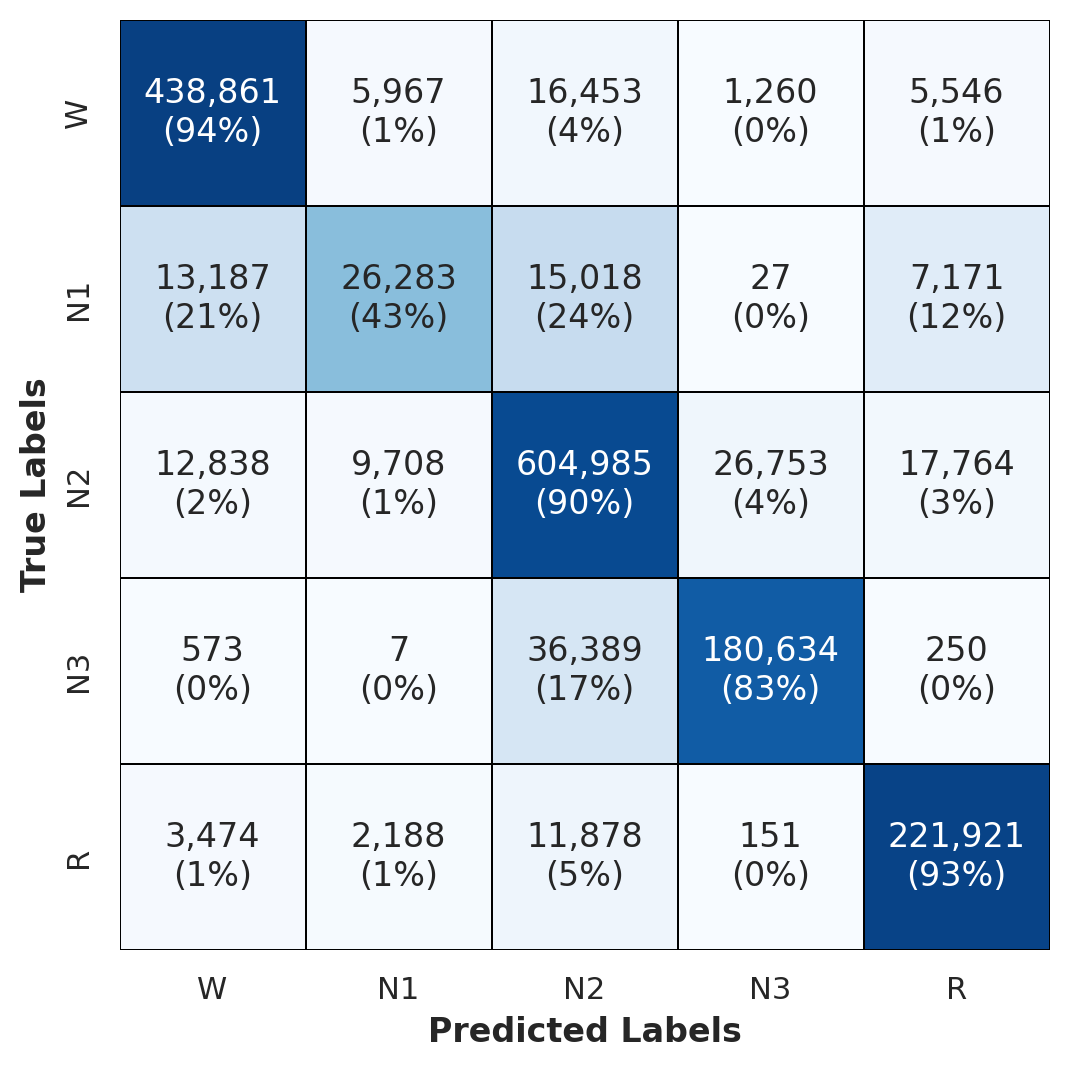

In [15]:
model.eval()

# list to hold predictions
y_pred_all = []
y_true_all = []

# no grad, loop
with torch.no_grad():
    for data in dl_test:
        # to device
        X_batch = data[0].to(device)
        true = data[1].to(device).ravel()

        # zero grad
        opt.zero_grad()

        # prediction
        pred = model(X_batch).argmax(axis=-1).ravel()

        # trim
        pred = pred[:true.shape[0]]
       
        # remove undefined ones
        pred = pred[true != 5]
        true = true[true != 5]

        # append to the lists
        y_pred_all += pred.tolist()
        y_true_all += true.tolist()


# print metrics
print(classification_report(y_true_all, y_pred_all, digits=3))
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_all, y_pred_all):.3f}")

# confusion matrix
plot_cm(y_true_all, y_pred_all, ["W", "N1", "N2", "N3", "R"])    